In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import clear_output
import openmm
from openmm import unit
import bgflow as bg
import bgmol
from bgflow.utils.types import assert_numpy
from bgmol.datasets.base import DataSet
from bgmol.api import system_by_name                                                                        
import mdtraj as md
import os
from bgmol.systems.base import OpenMMSystem
from bgmol.util.importing import import_openmm
_, unit, app = import_openmm()
kB = unit.MOLAR_GAS_CONSTANT_R.value_in_unit(unit.kilojoule_per_mole/unit.kelvin)
ctx = {'dtype': torch.float32, 'device': torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')}
main = (__name__ == "__main__")


Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [2]:

class AlaImplicit(OpenMMSystem):
    def __init__(
            self,
    ):
        super(AlaImplicit, self).__init__()

        forcefield = app.ForceField("amber14-all.xml", 'implicit/gbn2.xml')
        pdb = app.PDBFile("ala_no_water.pdb")

        self._system  = forcefield.createSystem(
            pdb.topology,
            nonbondedMethod=app.NoCutoff, 
            constraints=app.HBonds,  
            hydrogenMass=4.0 * unit.amu  
        )

        self._positions = pdb.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
        self._topology = pdb.topology


class Ala2Implicit300(DataSet):

    def __init__(self, root=os.getcwd(), download: bool = False, read: bool = False):
        super(Ala2Implicit300, self).__init__(root=root, download=download, read=read)
        self._system = AlaImplicit()
        self._temperature = 300

    @property
    def trajectory_file(self):
        return os.path.join(self.root, "/home/dell/workstations/hsj_bgflow/experiment/ala/Ala2Tip3p300/trajectory_aligned_no_water.dcd")

    @property
    def top_file(self):
        return os.path.join(self.root, "ala_no_water.pdb")

    def read(self, n_frames=None, stride=None, atom_indices=None):
        self.trajectory = md.load(self.trajectory_file, top = self.top_file)


class Ala2Implicit1000(DataSet):

    def __init__(self, root=os.getcwd(), download: bool = False, read: bool = False):
        super(Ala2Implicit1000, self).__init__(root=root, download=download, read=read)
        self._system = AlaImplicit()
        self._temperature = 1000

    @property
    def trajectory_file(self):
        return os.path.join(self.root, "/home/dell/workstations/hsj_bgflow/experiment/ala/Ala2Tip3p1000/trajectory_aligned_no_water.dcd")

    @property
    def top_file(self):
        return os.path.join(self.root, "ala_no_water.pdb")

    def read(self, n_frames=None, stride=None, atom_indices=None):
        self.trajectory = md.load(self.trajectory_file, top = self.top_file)

In [3]:
is_data_here = True
dataset_1 = Ala2Implicit1000(download=(not is_data_here), read=True)
system_1 = dataset_1.system
coordinates_1 = dataset_1.xyz
T_1= dataset_1.temperature
dataset_2 = Ala2Implicit300(download=(not is_data_here), read=False)
system_2 = dataset_2.system
coordinates_2 = dataset_2.coordinates
T_2= dataset_2.temperature

/home/dell/software/miniforge3/envs/bgflow/lib/python3.8/site-packages/mdtraj/formats/pdb/pdbfile.py:196: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn('Unlikely unit cell vectors detected in PDB file likely '


In [4]:
coordinates_1.shape

(5000000, 22, 3)

In [5]:
target_energy_1 = dataset_1.get_energy_model(n_workers=8)
target_energy_2 = dataset_2.get_energy_model(n_workers=8)

/home/dell/workstations/GREX/Ala2/bgflow/distribution/energy/openmm.py:200: UserWarning: It looks like you are using an OpenMMBridge with multiple workers in an ipython environment. This can behave a bit silly upon KeyboardInterrupt (e.g., kill the stdout stream). If you experience any issues, consider initializing the bridge with n_workers=1 in ipython/jupyter.
  warnings.warn(


In [ ]:
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split

class HighTempDataset(Dataset):
    def __init__(self, md_data, md_ener, ctx):
        assert len(md_data) == len(md_ener), "md_data and md_ener length mismatch"

        self.md_data   = torch.tensor(md_data, **ctx)
        self.md_ener   = torch.tensor(md_ener, **ctx)

    def __len__(self):
        return len(self.md_data)

    def __getitem__(self, idx):
        return {
            "md_data":   self.md_data[idx],
            "md_ener":   self.md_ener[idx]
        }


md_data   = coordinates_1[:5000]
md_ener   = system_1.energy(torch.tensor(coordinates_1.reshape(-1,66)).to(**ctx))

total_len = len(md_data)
len_training = int(total_len * 20 / 20)
md_data_subset = md_data[:len_training]
md_ener_subset = md_ener[:len_training]

dataset = HighTempDataset(md_data_subset, md_ener_subset, ctx)

subset_len = len(dataset)
train_len = int(subset_len * 0.8)
test_len  = subset_len - train_len
train_set, test_set = random_split(dataset, [train_len, test_len])


In [ ]:
total_len

500000

In [13]:
data_len = len(md_data)

indices = torch.randperm(data_len)

len_training = int(data_len * 0.5)
training_indices = indices[:len_training]
testing_indices = indices[len_training:]

training_data =  torch.tensor(md_data[training_indices]).to(**ctx)
testing_data =  torch.tensor(md_data[testing_indices]).to(**ctx)
# training_ener = torch.tensor(sampled_ener[training_indices]).to(**ctx)
# testing_ener = torch.tensor(sampled_ener[testing_indices]).to(**ctx)

# print(training_data.shape, testing_data.shape)
# print(training_ener.shape, testing_ener.shape)

/tmp/ipykernel_2369535/4137674024.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  training_data =  torch.tensor(md_data[training_indices]).to(**ctx)
/tmp/ipykernel_2369535/4137674024.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  testing_data =  torch.tensor(md_data[testing_indices]).to(**ctx)


In [14]:
import math
import numpy as np
import mdtraj as md 
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
model = dataset_1.system
def get_phi_psi(trajectory, model):
    if not isinstance(trajectory, md.Trajectory):
        if isinstance(trajectory, torch.Tensor):
            trajectory = assert_numpy(trajectory.view(len(trajectory), *model.positions.shape))
        trajectory = md.Trajectory(trajectory, model.mdtraj_topology)
    phi_atoms_list = md.compute_phi(trajectory)[0]
    psi_atoms_list = md.compute_psi(trajectory)[0]
    phi = md.compute_dihedrals(trajectory, indices=phi_atoms_list)
    psi = md.compute_dihedrals(trajectory, indices=psi_atoms_list)
    return phi, psi

def plot_phi_psi(phi_list, psi_list):
    if len(phi_list) != len(psi_list):
        raise ValueError("The dimensions of phi_list and psi_list must be the same.")

    if any(len(phi) != len(psi) for phi, psi in zip(phi_list, psi_list)):
        raise ValueError("The inner arrays of phi_list and psi_list must have the same length.")
    
    num_columns = 3
    num_rows = math.ceil(len(phi_list[0]) / num_columns)
    
    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 5 * num_rows))
    
    axs = axs.ravel()
    
    for i, ax in enumerate(axs):
        if i < len(phi_list[0]):
            phi = [p[i] for p in phi_list]
            psi = [ps[i] for ps in psi_list]
            ax.hist2d(phi, psi, bins=50, norm=LogNorm())
            ax.set_xlim(-np.pi, np.pi)
            ax.set_ylim(-np.pi, np.pi)
            ax.set_xlabel(f"$\phi_{i+1}(°)$", fontsize=14)
            ax.set_ylabel(f"$\psi_{i+1}(°)$", fontsize=14)
            # ax.set_title(f"Distribution {i+1}")
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

def process_and_plot_phi_psi(traj,model):
    """Process trajectory and plot 2D histogram of phi and psi."""
    phi_list, psi_list = get_phi_psi(traj,model)
    plot_phi_psi(phi_list, psi_list)


# MAP

In [15]:
from bgmol.zmatrix import ZMatrixFactory
from bgflow import TensorInfo, TORSIONS, FIXED, BONDS, ANGLES, ShapeDictionary

c_alpha = system_1.mdtraj_topology.select("name C or name N")
zfactory = ZMatrixFactory(system_1.mdtraj_topology, cartesian=c_alpha)
z_matrix, fixed_atoms = zfactory.build_naive()


In [16]:
from bgflow import Flow
from bgflow.nn.flow.crd_transform.ic_helper import (
    dist_deriv,
    angle_deriv,
    torsion_deriv,
    det3x3,
    init_xyz2ics,
    init_ics2xyz,
    ic2xyz_deriv,
)
from typing import Union, Optional


In [17]:
coordinate_transform = bg.RelativeInternalCoordinateTransformation(
    z_matrix=z_matrix,
    fixed_atoms=fixed_atoms,
    normalize_angles=True,).to(**ctx)

constrained_indices, constrained_lengths = bgmol.bond_constraints(
    system_1.system, coordinate_transform
)

shape_info = bg.ShapeDictionary.from_coordinate_transform(
    coordinate_transform,
    remove_origin_and_rotation=True,
    n_constraints=len(constrained_indices)
)
shape_info

ShapeDictionary([(TensorInfo(name='BONDS', is_circular=False, is_cartesian=False),
                  (5,)),
                 (TensorInfo(name='ANGLES', is_circular=False, is_cartesian=False),
                  (17,)),
                 (TensorInfo(name='TORSIONS', is_circular=True, is_cartesian=False),
                  (17,)),
                 (TensorInfo(name='FIXED', is_circular=False, is_cartesian=True),
                  (15,))])

In [18]:
CLIPPING = 100
target = system_2

if CLIPPING:
    grad_clipping = bg.utils.ClipGradient(clip=CLIPPING, norm_dim=3)
    target = bg.GradientClippedEnergy(target.energy_model, grad_clipping).to(**ctx)
    print('clipping atom forces at', CLIPPING) 

clipping atom forces at 100


## build Ca generator

In [19]:
builder = bg.BoltzmannGeneratorBuilder(shape_info, target, **ctx)

In [20]:
conditioner = "allegro"  # "allegro", "nequip", "schnet", ("wrapdistances"), ("ICs")

In [21]:
if conditioner == "allegro":
    from bgflow.factory.GNN_factory import allegro_hparams as hparams, make_allegro_config_dict as make_config_dict
if conditioner in ["nequip", "schnet"]:
    from bgflow.factory.GNN_factory import nequip_hparams as hparams, make_nequip_config_dict as make_config_dict

from bgflow.nn.periodic import WrapDistances

/home/dell/software/miniforge3/envs/bgflow/lib/python3.8/site-packages/nequip/__init__.py:20: UserWarning: !! PyTorch version 2.4.0.post301 found. Upstream issues in PyTorch versions 1.13.* and 2.* have been seen to cause unusual performance degredations on some CUDA systems that become worse over time; see https://github.com/mir-group/nequip/discussions/311. The best tested PyTorch version to use with CUDA devices is 1.11; while using other versions if you observe this problem, an unexpected lack of this problem, or other strange behavior, please post in the linked GitHub issue.
  warnings.warn(


In [22]:
if conditioner in ["schnet", "allegro", "nequip"]:
    ### gather some data to initialize the RBF to be normalized
    distances_net = WrapDistances(torch.nn.Identity())
    fixed = coordinate_transform.forward(training_data[:1000])[3]
    RBF_distances = distances_net(fixed.detach()).flatten().cpu()
    RBF_distances = RBF_distances[RBF_distances<=hparams["r_max"]]

    avg_num_neighbors = ((len(RBF_distances)/(1000*fixed.shape[1]/3)))*2

    layers = make_config_dict(**hparams)
    layers["radial_basis"][1]["basis_kwargs"]["data"] = RBF_distances

    if conditioner == "allegro":
        layers["allegro"][1]["avg_num_neighbors"]= avg_num_neighbors

    if conditioner in ["nequip", "schnet"]:
        for i in range(hparams["num_interaction_blocks"]):
            layers[f"convnet_{i}"][1]["convolution_kwargs"]["avg_num_neighbors"]= avg_num_neighbors

        if conditioner == "schnet":
            hparams["irreps_edge_sh"] = "1x0e" ## this reduces nequip GNN to schnet basically.
    from nequip.nn import SequentialGraphNetwork
    # the layers object is a config dict, that contains all we need to construct a nequip GNN
    GNN = SequentialGraphNetwork.from_parameters(shared_params=None, layers=layers)

    from bgflow.factory.GNN_factory import NequipWrapper
    # the GNN has to be wrapped to return a Tensor, not a nequip "AtomicDataDict"
    GNN_feature_extractor = NequipWrapper(GNN, cutoff = hparams["r_max"])

In [23]:
### when the networks becomes to large to fit on the GPU you can use gradient checkpointing to trade memory cost for computation time
use_checkpointing = False 

In [24]:
if conditioner in ["allegro", "nequip", "schnet"]:
    builder.default_conditioner_type = "GNN"
    builder.default_conditioner_kwargs = {
                                          "r_max": hparams["r_max"],
                                          "GNN": GNN_feature_extractor,  #1
                                          #"GNN": nequip_wrapper,  #2
                                          #"GNN_kwargs": {"shared_params": None,
                                          #               "layers": layers
                                          #              },
                                          "use_checkpointing": False,
                                          "GNN_output_dim": hparams["GNN_feature_dim"]*len(c_alpha),
                                          "attention_units": len(c_alpha),  #"atomwise",
                                          "attention_level": "MHA" #MHA ,Transformer
                                         }

In [25]:
if conditioner == "wrapdistances":
    from bgflow.factory.GNN_factory import WrapDistancesGNN
    builder.default_conditioner_type = "GNN"
    num_basis = 32
    builder.default_conditioner_kwargs = {
                                          "r_max": 1.2,
                                          "GNN": WrapDistancesGNN,
                                          "GNN_kwargs": {"num_basis": num_basis,
                                                         "r_max": 15,
                                                         "env_p": 48
                                                          },
                                          "use_checkpointing": True,  # False,
                                          "GNN_output_dim": (len(c_alpha)**2-len(c_alpha))//2*num_basis,  
                                          "attention_units": (len(c_alpha)**2-len(c_alpha))//2,
                                          "attention_level": "Transformer"
                                         }

In [26]:
if conditioner == "ICs":
    builder.default_conditioner_type = "dense"
    builder.default_conditioner_kwargs = {
                                          }
    CA_REP = [CA_BONDS, CA_ANGLES, CA_TORSIONS]    ##the CA structure is represented using CA ICs
else:
    CA_REP =[FIXED] 

In [27]:
from bgflow import InternalCoordinateMarginals
from bgmol import bond_constraints


In [28]:
n_torsions = builder.current_dims[TORSIONS][-1]
t1, t2 = builder.add_split(
    TORSIONS,
    into=["T1", "T2"],
    sizes_or_indices=[np.arange(0,n_torsions,2), np.arange(1,n_torsions,2)]
)
for i in range(4):
    builder.add_condition(
        t1, on=(*CA_REP, t2),
        hidden=(256, 256),
        param_groups=("aa", "torsions")
    )
    builder.add_condition(
        t2, on=(t1, *CA_REP),
        hidden=(256, 256),
        param_groups=("aa", "torsions")
    )
builder.add_merge(
    (t1, t2),
    to=TORSIONS,
    sizes_or_indices=[np.arange(0,n_torsions,2), np.arange(1,n_torsions,2)]
)

/home/dell/workstations/hsj_bgflow/experiment/ala/bgflow/nn/flow/transformer/spline.py:80: UserWarning: your nflows version does not support 'enable_identity_init'.See https://github.com/bayesiains/nflows/pull/65
  warnings.warn(


TensorInfo(name='TORSIONS', is_circular=True, is_cartesian=False)

In [29]:
for i in range(2):
    builder.add_condition(
        BONDS,
        on=(ANGLES,*CA_REP, TORSIONS ),
        hidden=(256, 256),
        param_groups=("aa",)
    )
    builder.add_condition(
        ANGLES,
        on=(BONDS, TORSIONS, *CA_REP),
        hidden=(256, 256),
        param_groups=("aa",)
    )

In [30]:
cdfs = InternalCoordinateMarginals(
    builder.current_dims,
    builder.ctx,
    bonds=BONDS,
    angles=ANGLES,
    torsions=None,#TORSIONS,
    fixed=None,
    bond_mu=0.2,
    bond_sigma=2.0,
    bond_upper=1.0,
    bond_lower=0.03,
    #angle_mu=0.7,
    angle_lower=0.1,
    angle_upper=0.9
)

In [ ]:

generator = builder.build_generator(zero_parameters=True)  


/home/dell/workstations/hsj_bgflow/experiment/ala/bgflow/factory/generator_builder.py:176: UserWarning: Initializing the flow with zeros makes it much less flexible
  warnings.warn("Initializing the flow with zeros makes it much less flexible", UserWarning)
/home/dell/workstations/hsj_bgflow/experiment/ala/bgflow/factory/generator_builder.py:223: UserWarning: No target energy for TensorInfo(name='BONDS', is_circular=False, is_cartesian=False).
  warnings.warn(f"No target energy for {field}.", UserWarning)
/home/dell/workstations/hsj_bgflow/experiment/ala/bgflow/factory/generator_builder.py:223: UserWarning: No target energy for TensorInfo(name='ANGLES', is_circular=False, is_cartesian=False).
  warnings.warn(f"No target energy for {field}.", UserWarning)
/home/dell/workstations/hsj_bgflow/experiment/ala/bgflow/factory/generator_builder.py:223: UserWarning: No target energy for TensorInfo(name='TORSIONS', is_circular=True, is_cartesian=False).
  warnings.warn(f"No target energy for {fie

In [32]:
# center_flow = builder.build_flow(zero_parameters=True)

In [33]:
edge_flow = []
# center_flow = builder.build_flow(zero_parameters=True)
for _ in range(2):
    builder = bg.BoltzmannGeneratorBuilder(shape_info, target, **ctx)
    builder.add_merge_constraints(constrained_indices, constrained_lengths)
    builder.add_map_to_cartesian(coordinate_transform)
    edge_flow.append(builder.build_flow())
bgmap = bg.SequentialFlow([bg.InverseFlow(edge_flow[0]), generator._flow , edge_flow[1]])
# bgmap = bg.SequentialFlow([generator._flow ])
tot_param = sum(p.numel() for p in bgmap.parameters() if p.requires_grad)
print(f"Number of Parameters: {tot_param:_}")

Number of Parameters: 2_250_572


# Map train

In [34]:
learning_rate = 1e-3
batch_size = 2**8

optimizer = torch.optim.Adam(bgmap.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')
dataset = HighTempDataset(md_data, md_ener, ctx)
dataloader = torch.utils.data.DataLoader(
    dataset, 
    batch_size=batch_size, shuffle=True
)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

reporter = [np.nan]
test_reporter = []
def test_loss_once(dataloader, loss_fn, test_reporter=None,
                   myflow=bgmap, mytarget=target,
                   lambda_energy=1.0, lambda_rmsd=0.0, lambda_dlogp=0.0,
                   test=True):
    """Test loss on first batch of dataloader and print terms. lambda_rmsd/lambda_dlogp can be tuned."""
    with torch.no_grad():
        for batch in dataloader:
            prior_samples = batch["md_data"]
            prior_energies = batch["md_ener"]

            loss = loss_fn(prior_samples, prior_energies,
                           myflow=myflow, mytarget=mytarget,
                           lambda_energy=lambda_energy,
                           lambda_rmsd=lambda_rmsd,
                           lambda_dlogp=lambda_dlogp,
                           test=test)

            print(f"Test batch loss: {loss.item():.6f}")

            if test_reporter is not None:
                test_reporter.append(loss.item())

            break
    return loss


/tmp/ipykernel_2369535/4117868028.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.md_data   = torch.tensor(md_data, **ctx)
/tmp/ipykernel_2369535/4117868028.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.md_ener   = torch.tensor(md_ener, **ctx)


In [35]:
def compute_rmsd(x, y, eps=1e-8):
    """
    x, y: (batch, n_features)
    """
    diff = x - y
    return torch.sqrt((diff ** 2).mean(dim=1) + eps)

def KLloss(prior_samples, prior_energies, 
           myflow=bgmap, mytarget=target,
           lambda_energy=0.0, lambda_rmsd=1e3, lambda_dlogp=1.,
           test=False):
    """
    prior_samples: high-T coordinates; prior_energies: high-T energies.
    """
    mapped_samples, dlogp = myflow(prior_samples)

    kl_term = (mytarget.energy(mapped_samples) - dlogp - prior_energies).mean()

    dlogp_reg = (dlogp**2).mean()

    loss = kl_term \
         + lambda_dlogp * dlogp_reg

    if test:
        print(f"KL term: {kl_term.item():.6f}")
        print(f"dlogp reg term: {lambda_dlogp * dlogp_reg.item():.6f}")
        print(f"Total loss: {loss.item():.6f}")
        print(f"dlogp mean: {dlogp.mean().item():.6f}, std: {dlogp.std().item():.6f}")

    return loss

class LambdaScheduler:
    def __init__(self, start=0.0, end=1.0, n_epochs=100, mode="linear"):
        self.start = start
        self.end = end
        self.n_epochs = n_epochs
        self.mode = mode

    def get(self, epoch):
        if self.mode == "linear":
            alpha = min(epoch / self.n_epochs, 1.0)
            return self.start + (self.end - self.start) * alpha
        elif self.mode == "exp":
            return self.start * ((self.end / self.start) ** (epoch / self.n_epochs))
        else:
            return self.end


def train_loop(dataloader, loss_fn, optimizer, reporter, threshold=2e5, clip_grad=1.0):
    size = len(dataloader.dataset)
    epoch_losses = []

    for batch_idx, batch in enumerate(dataloader):
        prior_samples = batch["md_data"]
        prior_energies = batch["md_ener"]

        loss = loss_fn(prior_samples, prior_energies)

        if torch.isnan(loss):
            print(f"[Batch {batch_idx}] Loss is NaN, skipping.")
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bgmap.parameters(), max_norm=clip_grad)
        optimizer.step()

        epoch_losses.append(loss.item())
        # if (batch_idx + 1) % 10 == 0:
        #     reporter.append(loss.item())
        #     print(f"[{(batch_idx+1)*prior_samples.shape[0]:>6d}/{size:>6d}] "
        #           f"Loss: {loss.item():.6f}", end="\r")

    avg_loss = np.mean(epoch_losses) if epoch_losses else float('nan')
    reporter.append(avg_loss)
    return avg_loss


In [36]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="InputOutsideDomain")

train_reporter = []
test_reporter = []
n_epochs = 5
test_chunk = 1000
flow_is_identity = False

print(f"\n=== Test ===")
print("-"*40)

dlogp_scheduler = LambdaScheduler(start=0.00, end=0.00, n_epochs=n_epochs, mode="linear")

for epoch in range(n_epochs):
    lambda_dlogp = dlogp_scheduler.get(epoch)

    print(f"[Epoch {epoch+1}]")

    avg_train_loss = train_loop(
        train_loader,
        lambda prior_samples, prior_energies: KLloss(
            prior_samples, prior_energies, 
            myflow=bgmap, mytarget=target,
            lambda_dlogp=lambda_dlogp
        ),
        optimizer, train_reporter
    )
    print(f"Epoch {epoch+1} average train loss: {avg_train_loss:.6f}\n")

    test_loss = test_loss_once(
        test_loader, KLloss, test_reporter,
        myflow=bgmap, mytarget=target,
        lambda_dlogp=lambda_dlogp, test=True
    )
    test_reporter.append(test_loss.item())
    scheduler.step(avg_train_loss)
    print("-"*40)



=== Test ===
----------------------------------------
[Epoch 1]


/home/dell/workstations/hsj_bgflow/experiment/ala/bgflow/nn/flow/crd_transform/ic_helper.py:283: UserWarning: singular division in torsion computation
  warnings.warn("singular division in torsion computation")


Epoch 1 average train loss: 0.888084

KL term: -1.755940
dlogp reg term: 0.000000
Total loss: -1.755940
dlogp mean: -19.418610, std: 0.793201
Test batch loss: -1.755940
----------------------------------------
[Epoch 2]
Epoch 2 average train loss: -1.488967

KL term: 4.891403
dlogp reg term: 0.000000
Total loss: 4.891403
dlogp mean: -19.280621, std: 0.857898
Test batch loss: 4.891403
----------------------------------------
[Epoch 3]
Epoch 3 average train loss: -1.543533

KL term: -1.058480
dlogp reg term: 0.000000
Total loss: -1.058480
dlogp mean: -19.359461, std: 0.764567
Test batch loss: -1.058480
----------------------------------------
[Epoch 4]
Epoch 4 average train loss: -1.571926

KL term: -2.100653
dlogp reg term: 0.000000
Total loss: -2.100653
dlogp mean: -19.309355, std: 0.670061
Test batch loss: -2.100653
----------------------------------------
[Epoch 5]
Epoch 5 average train loss: -1.586521

KL term: -1.834706
dlogp reg term: 0.000000
Total loss: -1.834706
dlogp mean: -19

Process Worker-23:
Process Worker-12:
Process Worker-19:
Process Worker-15:
Process Worker-2:
Process Worker-11:
Process Worker-29:
Process Worker-6:
Process Worker-26:
Process Worker-9:
Process Worker-1:
Process Worker-20:
Process Worker-28:
Process Worker-14:
Process Worker-16:
Process Worker-18:
Process Worker-22:
Process Worker-8:
Traceback (most recent call last):
Process Worker-31:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process Worker-27:
Process Worker-21:
Traceback (most recent call last):
Traceback (most recent call last):
Process Worker-3:
Process Worker-24:
Process Worker-4:
Traceback (most recent call last):
Process Worker-13:
Traceback (most recent call last):
Process Worker-7:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process Worker-10:
Process Worker-30:
Process Worker-25:
Traceback (most recent call last):
Pr

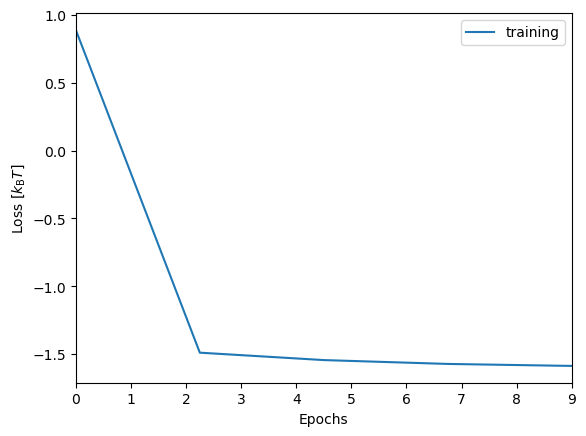

In [37]:
it = np.arange(len(train_reporter)) / (len(train_reporter)-1) * (len(test_reporter)-1)
plt.plot(it, train_reporter, label='training')
# plt.plot(test_reporter, '--o', label='testing')
plt.xlim(0, it[-1])
plt.ylabel('Loss [$k_\mathrm{B}T$]')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [36]:
# torch.save(bgmap.state_dict(), 'models/BGmap_ala_20ns.pth')
bgmap.load_state_dict(torch.load('models/BGmap_ala_20ns.pth'))
bgmap.eval()

/tmp/ipykernel_2369535/4138566125.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bgmap.load_state_dict(torch.load('models/BGmap_ala_20ns.pth'))


SequentialFlow(
  (_blocks): ModuleList(
    (0): InverseFlow(
      (_delegate): SequentialFlow(
        (_blocks): ModuleList(
          (0): SetConstantFlow()
          (1): WrapFlow(
            (_flow): MergeFlow(
              (_delegate): SplitFlow()
            )
          )
          (2): WrapFlow(
            (_flow): InverseFlow(
              (_delegate): RelativeInternalCoordinateTransformation()
            )
          )
        )
      )
    )
    (1): SequentialFlow(
      (_blocks): ModuleList(
        (0): WrapFlow(
          (_flow): SplitFlow()
        )
        (1): CouplingFlow(
          (transformer): ConditionalSplineTransformer(
            (_params_net): WrapPeriodic(
              (net): GNNConditioner(
                (GNN): NequipWrapper(
                  (GNN): SequentialGraphNetwork(
                    (one_hot): OneHotAtomEncoding()
                    (radial_basis): RadialBasisEdgeEncoding(
                      (basis): NormalizedBasis(
           

In [37]:
# prior_name = target_name = "ChignolinC22Implicit"
DF = 0

# =======================
# Analyze and plot using test_loader
# =======================
with torch.no_grad():
    for batch in test_loader:
        prior_samples = batch["md_data"]
        prior_energies = batch["md_ener"]

        mapped_data, dlogp = bgmap(prior_samples)
        mapped_ene = system_2.energy(mapped_data)
        mapped_data = mapped_data.cpu()

        logw = (prior_energies + dlogp - mapped_ene).view(-1).cpu()
        kl_distance = - logw.mean().item() - DF
        print(f'Final KL distance: {kl_distance:g}')

        logw = logw - torch.logsumexp(logw, dim=-1)

        ESS = bg.effective_sample_size(logw).item()
        print(f'Effective sample size: {ESS:g}')
        print(f'Sampling efficiency: {ESS/len(logw):e}')
        print(f'Sampling efficiency: {ESS/len(logw):.2%}')

        # =======================
        # Phi/Psi analysis
        # =======================
        # print('mapped set')
        # process_and_plot_phi_psi(mapped_data, system_2)

        break


Final KL distance: -2.24922
Effective sample size: 4.63679
Sampling efficiency: 1.811244e-02
Sampling efficiency: 1.81%


Process Worker-1:
Process Worker-28:
Process Worker-3:
Process Worker-8:
Process Worker-2:
Process Worker-5:
Process Worker-15:
Process Worker-11:
Process Worker-17:
Process Worker-6:
Process Worker-13:
Process Worker-7:
Process Worker-21:
Process Worker-20:
Process Worker-9:
Process Worker-32:
Process Worker-10:
Process Worker-23:
Process Worker-30:
Process Worker-29:
Process Worker-26:
Process Worker-24:
Process Worker-27:
Process Worker-25:
Process Worker-31:
Process Worker-22:
Process Worker-14:
Traceback (most recent call last):
Traceback (most recent call last):
Process Worker-18:
Traceback (most recent call last):
Process Worker-4:
Process Worker-12:
Traceback (most recent call last):
Process Worker-19:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/dell/software/minifor

# GREX

In [52]:
import numpy as np
import torch

xyz_new = np.load('./traindata_results/ala_BGgen_GNN_mini_20ns.npy')
sample = xyz_new

batch_size = 10000
z_list = []
dlogp_list = []
logw_h_list = []

with torch.no_grad():
    for i in range(0, len(sample), batch_size):
        batch = sample[i:i+batch_size]
        batch_tensor = torch.Tensor(batch.reshape(-1, 22*3)).to(**ctx)

        z_l, dlogp_h = bgmap(batch_tensor)
        energy_1 = system_1.energy(batch_tensor)
        energy_2 = system_2.energy(z_l)

        # logw_h = energy_1 + dlogp_h - energy_2
        # logw_h = energy_1 - energy_2
        logw_h = - energy_2 + dlogp_h


        z_list.append(z_l.cpu())
        dlogp_list.append(dlogp_h.cpu())
        logw_h_list.append(logw_h.cpu())

z_l_all = torch.cat(z_list, dim=0).to(**ctx)
dlogp_all = torch.cat(dlogp_list, dim=0).to(**ctx)
logw_h_all = torch.cat(logw_h_list, dim=0).to(**ctx)


In [48]:
system_2.energy(batch_tensor)

tensor([[30.7682],
        [11.9614],
        [-0.9012],
        ...,
        [33.9708],
        [34.3152],
        [ 5.8273]], device='cuda:1')

In [87]:
dlogp_all

tensor([[-18.9302],
        [-20.0173],
        [-20.5281],
        ...,
        [-18.9991],
        [-19.6311],
        [-19.0597]], device='cuda:1')

In [53]:
logw_h_all.max()

tensor(24.5974, device='cuda:1')

In [54]:
%%time
from openmm.app import Simulation, PDBFile,ForceField,Modeller,PME,HBonds
from openmm import LangevinMiddleIntegrator, MonteCarloBarostat, Platform
from openmm.unit import kelvin, picosecond, femtosecond, nanometer, kilojoules_per_mole, bar
system_nowat = AlaImplicit()
platform = Platform.getPlatformByName('CUDA')
properties = {'DeviceIndex': '0'}


temperature = 300 * kelvin
timestep = 2 * femtosecond
pdb_file = '/home/dell/workstations/hsj_bgflow/experiment/ala/Ala2Tip3p300/ala_no_water.pdb'
pdb = PDBFile(pdb_file)
forcefield = ForceField('amber14-all.xml', 'amber14/tip3pfb.xml')
modeller = Modeller(pdb.topology, pdb.positions)
modeller.addSolvent(forcefield, model='tip3p', padding=1.2*unit.nanometer)
system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME,
                                 nonbondedCutoff=1.0*nanometer, constraints=HBonds)
system.addForce(MonteCarloBarostat(1*bar, temperature))                                 
integrator = LangevinMiddleIntegrator(temperature, 1/picosecond, timestep)
simulation = Simulation(modeller.topology, system, integrator, platform, properties)
simulation.context.setPositions(modeller.positions)
simulation.minimizeEnergy()
print('-------------equilibrating-------------', end='\r')
n_equil = 500
pace = 500
# simulation.step(n_equil*pace)

print('-------------MD-------------', end='\r')
n_iter = 10 ** 5
mc_stride = 100

data = np.zeros((n_iter, *system_1.positions.shape))
mapped_high = np.full((n_iter // mc_stride, *system_1.positions.shape), np.nan)
logw_high = np.full(n_iter // mc_stride, np.nan)
is_swapped = np.full(n_iter, False)
protein_residue_names = ['ALA', 'ACE', 'NME']
protein_atoms = [atom.index for atom in simulation.topology.atoms() if atom.residue.name in protein_residue_names]

for n in range(n_iter):
    simulation.step(pace)
    state = simulation.context.getState(getPositions=True)
    positions = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    protein_positions = positions[protein_atoms]
    data[n] = protein_positions

    if n % mc_stride == 0:
        with torch.no_grad():
            md_l = torch.as_tensor(data[n], **ctx).view(1, -1)

            # logw_2 = system_2.energy(md_l) + dlogp_l - system_1.energy(x_h)
            logw_2 = system_2.energy(md_l)
            # print(logw_2)

            logw_1_all = logw_h_all  # shape [N]
            z_l_all_tensor = z_l_all  # shape [N, D]

            delta_energy_all = -(logw_1_all + logw_2)

            neg_indices = torch.nonzero(delta_energy_all < 0).flatten()
            num_negative = neg_indices.numel()

            if num_negative > 0:
                rand_pos = torch.randint(0, num_negative, (1,)).item()
                rand_idx = neg_indices[rand_pos].item()
                map_l = z_l_all_tensor[rand_idx]
                logw_1 = logw_1_all[rand_idx]
                delta_energy = delta_energy_all[rand_idx].item()
            else:
                best_idx = torch.argmin(delta_energy_all)
                map_l = z_l_all_tensor[best_idx]
                logw_1 = logw_1_all[best_idx]
                delta_energy = delta_energy_all[best_idx].item()
            print(delta_energy)
        
        if (delta_energy <= 0.0 or np.random.rand() < np.exp(-delta_energy)) and logw_1 > 10:
            # print(logw_1,delta_energy)
            is_swapped[n] = True
            pos = map_l.clone()
            # forcefield = ForceField('amber14-all.xml', 'amber14/tip3pfb.xml')
            # modeller = Modeller(system_nowat._topology, pos.view(*system_1.positions.shape).cpu().numpy() * unit.nanometer)
            # modeller.addSolvent(forcefield, model='tip3p', padding=1.2*unit.nanometer)
            # system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME,
            #                      nonbondedCutoff=1.0*nanometer, constraints=HBonds)            
            # for atom in protein_atoms:
            #     system.getParticleMass(atom) 
            #     system.setParticleMass(atom, 0.0)
            # integrator = LangevinMiddleIntegrator(temperature, 1/picosecond, timestep)
            # simulation = Simulation(modeller.topology, system, integrator, platform, properties)
            # simulation.context.setPositions(modeller.positions)
            # simulation.minimizeEnergy()
            # simulation.step(50)
            # optimized_positions = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(unit.nanometer)
            
            forcefield = ForceField('amber14-all.xml', 'amber14/tip3pfb.xml')
            modeller = Modeller(system_nowat._topology, pos.view(*system_1.positions.shape).cpu().numpy() * unit.nanometer)
            modeller.addSolvent(forcefield, model='tip3p', padding=1.2*unit.nanometer)
            integrator = LangevinMiddleIntegrator(temperature, 1/picosecond, timestep)
            system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME,
                                 nonbondedCutoff=1.0*nanometer, constraints=HBonds)
            system.addForce(MonteCarloBarostat(1*bar, temperature))                     
            simulation = Simulation(modeller.topology, system, integrator, platform, properties)

            # simulation.context.setPositions(optimized_positions)
            simulation.context.setPositions(modeller.positions)

    print(f'sampling...  {(n+1)/n_iter:.1%}, accepted: {is_swapped.sum():g} of {(n+1)//mc_stride} ({mc_stride*is_swapped.sum()/(n+1):.2%})', end='\r')

19.128835678100586---------------------
7.892366409301758, accepted: 0 of 1 (0.00%)
7.164316177368164, accepted: 0 of 2 (0.00%)
2.207660675048828, accepted: 0 of 3 (0.00%)
4.423978805541992, accepted: 0 of 4 (0.00%)
3.571756362915039, accepted: 0 of 5 (0.00%)
4.436784744262695, accepted: 0 of 6 (0.00%)
10.303133010864258 accepted: 0 of 7 (0.00%)
11.836858749389648 accepted: 0 of 8 (0.00%)
11.086359024047852 accepted: 0 of 9 (0.00%)
11.586503982543945 accepted: 0 of 10 (0.00%)
32.11475372314453, accepted: 0 of 11 (0.00%)
0.34282493591308594accepted: 0 of 12 (0.00%)
3.185222625732422, accepted: 1 of 13 (7.69%)
12.745260238647461 accepted: 1 of 14 (7.14%)
10.984922409057617 accepted: 1 of 15 (6.67%)
7.134494781494141, accepted: 1 of 16 (6.25%)
12.597204208374023 accepted: 1 of 17 (5.88%)
10.396448135375977 accepted: 1 of 18 (5.56%)
15.227914810180664 accepted: 1 of 19 (5.26%)
9.032930374145508, accepted: 1 of 20 (5.00%)
8.538740158081055, accepted: 1 of 21 (4.76%)
13.260290145874023 accep

In [55]:
print(f'sampling...  {(n+1)/n_iter:.1%}, accepted: {is_swapped.sum():g} of {(n+1)//mc_stride} ({mc_stride*is_swapped.sum()/(n+1):.2%})', end='\r')

In [ ]:
trajectory = md.Trajectory(
    xyz=data.reshape(-1, 22, 3), 
    topology=system_1.mdtraj_topology
    )
trajectory.save_xtc('xxx.xtc')

In [ ]:
# process_and_plot_phi_psi(data,system_2)